In [24]:
import pickle
from part2_house_value_regression import Regressor
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [10]:
best_model = load_regressor()


Loaded model in part2_model.pickle



In [36]:
output_label = "median_house_value"

data = pd.read_csv("housing.csv") 

# Splitting input and output
X = data.loc[:, data.columns != output_label]
y = data.loc[:, [output_label]]

# Train/ val/ test split
X_train, X_test, y_train, y_test = train_test_split(X , y, test_size=0.1, random_state=42) 



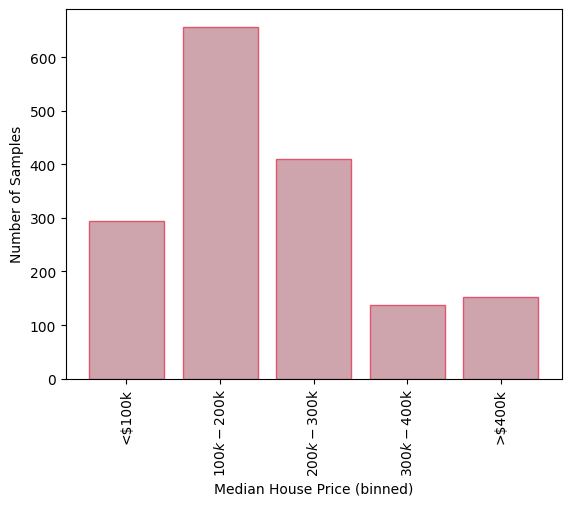

In [73]:
n_bins = 5  
bins = [0, 100000, 200000, 300000, 400000, float('inf')]
labels = ['<$100k', '$100k-$200k', '$200k-$300k', '$300k-$400k', '>$400k']
y_test_binned = pd.cut(y_test['median_house_value'], bins=bins, labels=labels, include_lowest=True, ordered=True)
y_test_binned.value_counts(sort=False).plot(kind='bar' , width = 0.8, color= '#cfa5ad',edgecolor="#e2556f")
plt.ylabel('Number of Samples')
plt.xlabel('Median House Price (binned)')
plt.savefig('visualisations/binned_distribution', bbox_inches='tight')
plt.show()


   Price Range  Sample Count          RMSE           MAE   MAPE (%)
0       <$100k           295  41510.546798  29970.912169  40.184824
1  $100k-$200k           657  45549.177424  32727.002568  22.748433
2  $200k-$300k           410  46645.444600  35456.047618  14.520287
3  $300k-$400k           137  61996.949220  48963.184307  13.996478
4       >$400k           153  99484.312554  74134.111111  15.694055


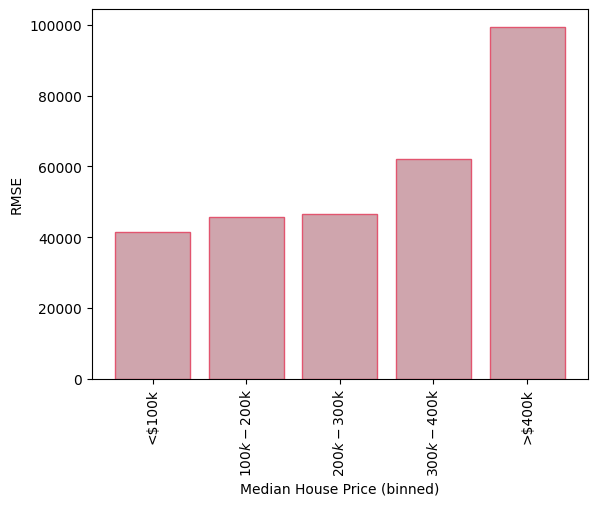

In [74]:
binned_results = []
y_pred = best_model.predict(X_test)

for bin in y_test_binned.cat.categories:
    labels_in_bin = y_test_binned == bin

    subset_pred = y_pred[labels_in_bin]
    subset_true = y_test[labels_in_bin]

    mse = np.mean((subset_true- subset_pred)**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(subset_true- subset_pred))
    mape = np.mean(np.abs((subset_true - subset_pred) / subset_true)) * 100

    binned_results.append({
        'Price Range': f"{bin}",
        'Sample Count': labels_in_bin.sum(),
        'RMSE': rmse,
        'MAE': mae,
        'MAPE (%)': mape
    })

results_df = pd.DataFrame(binned_results)
results_df.plot(x='Price Range', y='RMSE', kind='bar', width = 0.8, color= '#cfa5ad',edgecolor="#e2556f", legend=False)
plt.ylabel('RMSE')
plt.xlabel('Median House Price (binned)')
plt.savefig('visualisations/binned_errors', bbox_inches='tight')
print(results_df)
